# Building GPT from Scratch with PyTorch Lightning

This notebook is a PyTorch Lightning implementation of Andrej Karpathy's GPT tutorial. We'll build a character-level language model using the transformer architecture, training it on Shakespeare text to generate similar-looking text.

**What we'll build:**
- Character-level tokenizer
- Self-attention mechanism with causal masking
- Multi-head attention
- Feed-forward networks
- Complete transformer decoder blocks
- Text generation with the trained model

**Key differences from the raw PyTorch version:**
- Uses PyTorch Lightning for cleaner training code
- Automatic device management
- CSV logging of metrics
- Training time tracking
- Training/validation curves visualization

**Key concepts:**
- Causal (masked) self-attention for autoregressive generation
- Multi-head attention for learning different representation subspaces
- Residual connections and layer normalization
- Positional embeddings to encode token positions

## Configuration

We define all hyperparameters at the top for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    'seed': 1337,  # Random seed for reproducibility
    
    # Data
    'batch_size': 64,  # Number of sequences per batch
    'block_size': 256,  # Maximum context length for predictions
    
    # Model architecture
    'n_embed': 384,  # Embedding dimension
    'n_layers': 6,  # Number of transformer blocks
    'n_heads': 6,  # Number of attention heads
    'dropout': 0.2,  # Dropout probability
    
    # Training
    'learning_rate': 3e-4,  # AdamW learning rate
    'max_steps': 5000,  # Maximum training steps
    'eval_interval': 100,  # Validation check interval
    'eval_iters': 200,  # Number of batches for loss estimation
}

## Setup: Random Seed

Set the random seed for reproducibility across all libraries.

In [2]:
from aiml_notebooks import set_seed

set_seed(CONFIG['seed'])

## Load and Prepare Data

We'll use the Tiny Shakespeare dataset - a collection of Shakespeare's works that's perfect for character-level language modeling.

In [3]:
import requests

# Download the Shakespeare dataset
response = requests.get("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt")
text = response.text

print(f"Dataset length: {len(text)} characters")
print(f"\nFirst 1000 characters:")
print(text[:1000])

Dataset length: 1115394 characters

First 1000 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
s

## Build Character-Level Tokenizer

Create a simple character-level vocabulary and encoding/decoding functions.

In [4]:
# Get all unique characters and create mappings
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")
print(f"\nExample encoding:")
print(f"  'hello' -> {encode('hello')}")
print(f"  {encode('hello')} -> '{decode(encode('hello'))}'")

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Example encoding:
  'hello' -> [46, 43, 50, 50, 53]
  [46, 43, 50, 50, 53] -> 'hello'


## Create Train/Val Split

Split the data into training and validation sets (90/10 split).

In [5]:
import torch

# Encode entire dataset and split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Training tokens: {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

Training tokens: 1,003,854
Validation tokens: 111,540


## Lightning DataModule

Create a PyTorch Lightning DataModule to handle data loading and batching.

In [6]:
import lightning as L
from torch.utils.data import Dataset, DataLoader

class CharDataset(Dataset):
    """Character-level dataset that returns random sequences."""
    
    def __init__(self, data, block_size, num_samples):
        self.data = data
        self.block_size = block_size
        self.num_samples = num_samples
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Random start position
        i = torch.randint(len(self.data) - self.block_size, (1,)).item()
        x = self.data[i:i+self.block_size]
        y = self.data[i+1:i+self.block_size+1]
        return x, y

class ShakespeareDataModule(L.LightningDataModule):
    """DataModule for Shakespeare character-level data."""
    
    def __init__(self, train_data, val_data, batch_size, block_size, eval_iters):
        super().__init__()
        self.train_data = train_data
        self.val_data = val_data
        self.batch_size = batch_size
        self.block_size = block_size
        self.eval_iters = eval_iters
    
    def train_dataloader(self):
        # Create dataset with samples equal to max_steps * batch_size
        dataset = CharDataset(self.train_data, self.block_size, num_samples=100000)
        return DataLoader(dataset, batch_size=self.batch_size, num_workers=0)
    
    def val_dataloader(self):
        # Fixed validation set for consistent evaluation
        dataset = CharDataset(self.val_data, self.block_size, 
                            num_samples=self.eval_iters * self.batch_size)
        return DataLoader(dataset, batch_size=self.batch_size, num_workers=0)

# Create data module
datamodule = ShakespeareDataModule(
    train_data=train_data,
    val_data=val_data,
    batch_size=CONFIG['batch_size'],
    block_size=CONFIG['block_size'],
    eval_iters=CONFIG['eval_iters']
)

print(f"DataModule created")
print(f"  Training samples per epoch: {len(datamodule.train_dataloader().dataset):,}")
print(f"  Validation samples: {len(datamodule.val_dataloader().dataset):,}")

DataModule created
  Training samples per epoch: 100,000
  Validation samples: 12,800


## Self-Attention Head

Implement a single self-attention head with causal masking. This prevents tokens from attending to future positions.

In [7]:
import torch.nn as nn
from torch.nn import functional as F

class Head(nn.Module):
    """Single head of self-attention with causal masking."""
    
    def __init__(self, head_size, n_embed, block_size, dropout):
        super().__init__()
        self.key = nn.Linear(n_embed, head_size, bias=False)
        self.query = nn.Linear(n_embed, head_size, bias=False)
        self.value = nn.Linear(n_embed, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)    # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)
        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * C**-0.5  # (B, T, T)
        # Apply causal mask
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        # Apply attention to values
        v = self.value(x)  # (B, T, head_size)
        out = wei @ v      # (B, T, head_size)
        return out

## Multi-Head Attention

Combine multiple attention heads in parallel. Each head can learn different aspects of the relationships between tokens.

In [8]:
class MultiHeadAttention(nn.Module):
    """Multiple heads of self-attention in parallel."""
    
    def __init__(self, num_heads, head_size, n_embed, block_size, dropout):
        super().__init__()
        self.heads = nn.ModuleList([
            Head(head_size, n_embed, block_size, dropout) 
            for _ in range(num_heads)
        ])
        self.proj = nn.Linear(n_embed, n_embed)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

## Feed-Forward Network

A simple feed-forward network applied to each position independently. This adds non-linearity and processing capacity.

In [9]:
class FeedForward(nn.Module):
    """Simple feed-forward network with ReLU activation."""
    
    def __init__(self, n_embed, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, 4 * n_embed),
            nn.ReLU(),
            nn.Linear(4 * n_embed, n_embed),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        return self.net(x)

## Transformer Block

A complete transformer decoder block with:
1. Multi-head self-attention
2. Feed-forward network
3. Residual connections and layer normalization

In [10]:
class Block(nn.Module):
    """Transformer decoder block: communication followed by computation."""
    
    def __init__(self, n_embed, n_heads, block_size, dropout):
        super().__init__()
        head_size = n_embed // n_heads
        self.sa = MultiHeadAttention(n_heads, head_size, n_embed, block_size, dropout)
        self.ffwd = FeedForward(n_embed, dropout)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)
    
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## Complete GPT Model with PyTorch Lightning

Assemble all components into a complete language model using Lightning's `LightningModule`. This handles training logic, optimization, and logging.

In [11]:
import time

class GPTLanguageModel(L.LightningModule):
    """Complete GPT language model with Lightning."""
    
    def __init__(self, vocab_size, n_embed=CONFIG['n_embed'], 
                 n_layers=CONFIG['n_layers'], n_heads=CONFIG['n_heads'],
                 block_size=CONFIG['block_size'], dropout=CONFIG['dropout'],
                 learning_rate=CONFIG['learning_rate']):
        super().__init__()
        self.save_hyperparameters()
        self.block_size = block_size
        
        # Model components
        self.token_embedding_table = nn.Embedding(vocab_size, n_embed)
        self.position_embedding_table = nn.Embedding(block_size, n_embed)
        self.blocks = nn.Sequential(*[
            Block(n_embed, n_heads, block_size, dropout) 
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(n_embed)
        self.lm_head = nn.Linear(n_embed, vocab_size)
        
        # Training time tracking
        self.train_start_time = None
        self.total_train_time = 0.0
    
    def forward(self, idx, targets=None):
        B, T = idx.shape
        
        # Embeddings
        tok_emb = self.token_embedding_table(idx)  # (B, T, C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))  # (T, C)
        x = tok_emb + pos_emb  # (B, T, C)
        
        # Transformer blocks
        x = self.blocks(x)  # (B, T, C)
        x = self.ln_f(x)    # (B, T, C)
        
        # Language modeling head
        logits = self.lm_head(x)  # (B, T, vocab_size)
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat = targets.view(B*T)
            loss = F.cross_entropy(logits_flat, targets_flat)
        
        return logits, loss
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits, loss = self(x, y)
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits, loss = self(x, y)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def on_train_start(self):
        """Record training start time."""
        self.train_start_time = time.time()
    
    def on_train_batch_end(self, outputs, batch, batch_idx):
        """Update elapsed training time."""
        if self.train_start_time is not None:
            self.total_train_time = time.time() - self.train_start_time
            self.log('train_time_seconds', self.total_train_time, prog_bar=False)
    
    def on_train_end(self):
        """Log final training time."""
        if self.train_start_time is not None:
            total_time = time.time() - self.train_start_time
            print(f"\nTotal training time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate)
    
    def generate(self, idx, max_new_tokens):
        """Generate new tokens autoregressively."""
        for _ in range(max_new_tokens):
            # Crop context to block_size
            idx_cond = idx[:, -self.block_size:]
            # Get predictions
            logits, _ = self(idx_cond)
            # Focus only on last time step
            logits = logits[:, -1, :]  # (B, C)
            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)  # (B, C)
            # Sample from distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)
        return idx

# Create model
model = GPTLanguageModel(vocab_size)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created")
print(f"  Total parameters: {total_params:,}")
print(f"  Embedding dimension: {CONFIG['n_embed']}")
print(f"  Number of layers: {CONFIG['n_layers']}")
print(f"  Number of heads: {CONFIG['n_heads']}")

Model created
  Total parameters: 10,788,929
  Embedding dimension: 384
  Number of layers: 6
  Number of heads: 6


## Test Generation Before Training

Generate text with the untrained model to see what random initialization produces.

In [12]:
from aiml_notebooks import get_device

device = get_device()
model_temp = model.to(device)
context = torch.zeros((1, 1), dtype=torch.long, device=device)

print("Generation before training:")
print(decode(model_temp.generate(context, max_new_tokens=100)[0].tolist()))

# Move model back to CPU for Lightning to manage
model = model.to('cpu')

Using CUDA GPU: NVIDIA GeForce RTX 4090
Generation before training:

SaVxul&f&&;gXYUCZo-TRuQigFmlHpkPkBj!'znSbirDynJ..SNKU.nIOMm&LHKHP;
qkjne nLRe!PpP!DAyCaDbT$Ib&KIGEJr


## Training Setup

Configure the Lightning Trainer with CSV logging to track metrics.

In [13]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint

# Create logger
logger = CSVLogger('logs', name='gpt_shakespeare')

# Create checkpoint callback to save best model
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_loss:.4f}'
)

# Create trainer
trainer = L.Trainer(
    max_steps=CONFIG['max_steps'],
    val_check_interval=CONFIG['eval_interval'],
    accelerator='auto',
    devices=1,
    logger=logger,
    callbacks=[checkpoint_callback],
    enable_progress_bar=True,
    log_every_n_steps=1
)

print(f"Trainer configured")
print(f"  Max steps: {CONFIG['max_steps']}")
print(f"  Validation interval: {CONFIG['eval_interval']} steps")
print(f"  Log directory: {logger.log_dir}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Trainer configured
  Max steps: 5000
  Validation interval: 100 steps
  Log directory: logs/gpt_shakespeare/version_1


## Train the Model

Run the training loop. Lightning handles device management, gradient updates, and logging automatically.

In [14]:
# Train the model
trainer.fit(model, datamodule)

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precis

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=5000` reached.



Total training time: 487.60 seconds (8.13 minutes)


## Plot Training Curves

Visualize how training and validation loss evolved over time, along with training time.

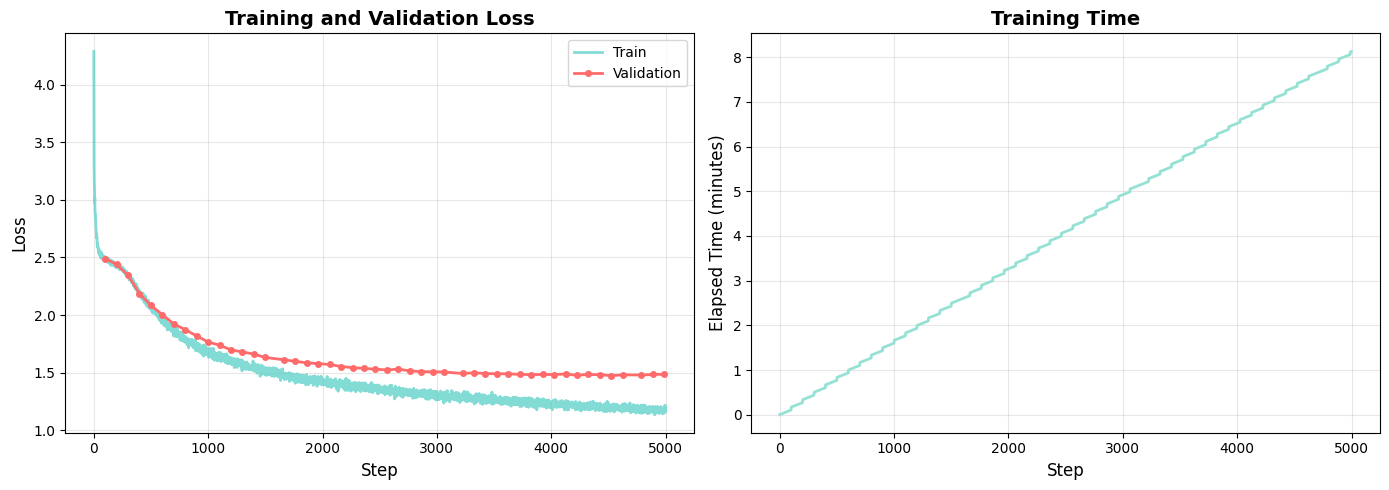


Training Statistics:
  Total steps: 5000
  Total time: 487.60s (8.13 minutes)

Final Results:
  Final train loss: 1.1864
  Final val loss: 1.4852
  Overfitting gap: 0.2988


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Read metrics from CSV logger
metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')

# Extract train and validation metrics
train_metrics = metrics[['step', 'train_loss_step']].dropna()
val_metrics = metrics[['step', 'val_loss']].dropna()
time_metrics = metrics[['step', 'train_time_seconds']].dropna()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_metrics['step'], train_metrics['train_loss_step'],
         label='Train', linewidth=2, alpha=0.7, color='#4ECDC4')
ax1.plot(val_metrics['step'], val_metrics['val_loss'],
         label='Validation', marker='o', linewidth=2, markersize=4, color='#FF6B6B')
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Training time
ax2.plot(time_metrics['step'], time_metrics['train_time_seconds'] / 60,
         linewidth=2, color='#95E1D3')
ax2.set_xlabel('Step', fontsize=12)
ax2.set_ylabel('Elapsed Time (minutes)', fontsize=12)
ax2.set_title('Training Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report training statistics
final_train_loss = train_metrics['train_loss_step'].iloc[-1]
final_val_loss = val_metrics['val_loss'].iloc[-1]
total_time = time_metrics['train_time_seconds'].iloc[-1]

print(f"\nTraining Statistics:")
print(f"  Total steps: {len(train_metrics)}")
print(f"  Total time: {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"\nFinal Results:")
print(f"  Final train loss: {final_train_loss:.4f}")
print(f"  Final val loss: {final_val_loss:.4f}")
print(f"  Overfitting gap: {final_val_loss - final_train_loss:.4f}")

## Generate Text with Trained Model

Use the trained model to generate new Shakespeare-like text.

In [16]:
# Move model to device and set to eval mode
model = model.to(device)
model.eval()

# Generate text
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_text = decode(model.generate(context, max_new_tokens=500)[0].tolist())

print("Generated text:")
print("="*80)
print(generated_text)
print("="*80)

Generated text:

Maid, or I'll stay down.

POLIXENES:
'Tis not.

AUFIDIUS:
What is the poison?

CORIOLANUS:
I have been kown, fair queen straight
As i' the night.

AUTOLYCUS:
He must be contented to be provided;
Being now incliness, but not they so.

ANGELO:
Tell't me on.

ANGELO:
Too, sir, if I accorded too the fair hence;
And yet I will draw ask him as offence.
Even troubles.

ANGELO:
Women, Juliet? Caesar, madam,
Boy; my lord, where I kiss the present at the Tower,
Call me not at thy foes! Thy wounds is adver


## Key Takeaways

**PyTorch Lightning Benefits:**
- **Cleaner code**: Training logic separated into `training_step` and `validation_step`
- **Automatic device management**: No manual `.to(device)` calls during training
- **Built-in logging**: CSV logger tracks all metrics automatically
- **Time tracking**: Easy to add custom metrics like training time
- **Checkpointing**: Automatic model saving based on validation loss

**Architecture Components:**
- **Self-attention**: Allows tokens to communicate and gather information from context
- **Multi-head attention**: Multiple attention mechanisms in parallel for richer representations
- **Feed-forward networks**: Per-token computation to process aggregated information
- **Residual connections**: Enable deep networks by providing gradient flow
- **Layer normalization**: Stabilizes training by normalizing activations

**Causal Masking:**
- Prevents tokens from attending to future positions
- Essential for autoregressive generation
- Implemented via triangular mask in attention weights

**Design Choices:**
- Character-level tokenization (simpler but less efficient than BPE)
- Learned positional embeddings (vs. sinusoidal)
- Pre-norm architecture (layer norm before attention/FFN)
- AdamW optimizer